# **Malaria Detection**

##<b>Problem Definition</b>
**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What is it that we are trying to solve using data science?

## <b>Data Description </b>

There are a total of 24,958 train and 2,600 test images (colored) that we have taken from microscopic images. These images are of the following categories:<br>


**Parasitized:** The parasitized cells contain the Plasmodium parasite which causes malaria<br>
**Uninfected:** The uninfected cells are free of the Plasmodium parasites<br>


###<b> Mount the Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### <b>Loading libraries</b>

In [ ]:
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np

import zipfile
import cv2
import os

In [ ]:
# Checking tensorflow version
!pip show tensorflow

Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras


### **Let us Unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same to your Google Drive. Then unzip the folder.

In [ ]:
# Path to the zip file on your Google Drive
zip_file_path = "/content/drive/MyDrive/MIT/Final_Projects/cell_images.zip"

# Extract the zip file to a temporary directory
extracted_path = "/content/cell_images"  # Specify the desired extraction path
os.makedirs(extracted_path, exist_ok=True) # Ensure the directory exists

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)

# Now the extracted files are in the specified directory
print(f"Dataset extracted to: {extracted_path}")


Dataset extracted to: /content/cell_images


### **Loading and Preparing**

In [ ]:
def load_images_from_folder(folder_path, label):
    images = []
    labels = []
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)
            labels.append(label)
    return images, labels

parasitized_train_images, parasitized_train_labels = load_images_from_folder("/content/cell_images/cell_images/train/parasitized", 1)
uninfected_train_images, uninfected_train_labels = load_images_from_folder("/content/cell_images/cell_images/train/uninfected", 0)
parasitized_test_images, parasitized_test_labels = load_images_from_folder("/content/cell_images/cell_images/test/parasitized", 1)
uninfected_test_images, uninfected_test_labels = load_images_from_folder("/content/cell_images/cell_images/test/uninfected", 0)

In [ ]:
# Aggregating all images and labels
X_train = parasitized_train_images + uninfected_train_images
y_train = parasitized_train_labels + uninfected_train_labels
X_test = parasitized_test_images + uninfected_test_images
y_test = parasitized_test_labels + uninfected_test_labels

In [ ]:
y_train = np.array(y_train)
y_test = np.array(y_test)

###<b> Check the shape of train and test images

In [ ]:
print("---- Training Set Info ----")
print("Amount of Images: ", len(X_train))
print("Amount of Labels: ", len(y_train))
print("Image Shape:", X_train[0].shape)

---- Training Set Info ----
Amount of Images:  24958
Amount of Labels:  24958
Image Shape: (103, 100, 3)


###<b> Check the shape of train and test labels

In [ ]:
# Defining the display function to reuse it, if necessary
def display_head(X, y, qtd=10):
    plt.figure(figsize=(15, 2))
    for i in range(qtd):
        plt.subplot(1, qtd, i + 1)
        plt.imshow(X[i])
        plt.title(f"Label: {y[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
print("---- Testing Set Info ----")
print("Amount of Images: ", len(X_test))
print("Amount of Labels: ", len(y_test))
print("Image Shape:", X_test[0].shape)

---- Testing Set Info ----
Amount of Images:  2600
Amount of Labels:  2600
Image Shape: (208, 166, 3)


In [ ]:
# Checking the shape's variance
training_shapes = [img.shape for img in X_train]
print(training_shapes)

[(103, 100, 3), (121, 142, 3), (151, 136, 3), (130, 124, 3), (118, 136, 3), (115, 118, 3), (115, 157, 3), (136, 127, 3), (133, 136, 3), (121, 127, 3), (109, 133, 3), (130, 124, 3), (124, 97, 3), (142, 142, 3), (178, 130, 3), (127, 133, 3), (136, 100, 3), (133, 118, 3), (109, 139, 3), (139, 148, 3), (118, 121, 3), (133, 139, 3), (121, 121, 3), (103, 97, 3), (172, 121, 3), (178, 172, 3), (112, 124, 3), (115, 109, 3), (127, 136, 3), (139, 118, 3), (145, 142, 3), (121, 100, 3), (172, 187, 3), (133, 133, 3), (121, 121, 3), (148, 124, 3), (172, 115, 3), (124, 133, 3), (85, 115, 3), (145, 145, 3), (130, 151, 3), (124, 133, 3), (142, 136, 3), (118, 121, 3), (106, 103, 3), (145, 121, 3), (133, 94, 3), (103, 103, 3), (130, 124, 3), (148, 145, 3), (190, 193, 3), (133, 109, 3), (106, 109, 3), (145, 121, 3), (133, 136, 3), (103, 100, 3), (145, 139, 3), (136, 136, 3), (148, 136, 3), (151, 133, 3), (94, 88, 3), (127, 124, 3), (145, 133, 3), (94, 103, 3), (136, 145, 3), (145, 160, 3), (148, 172, 3), (

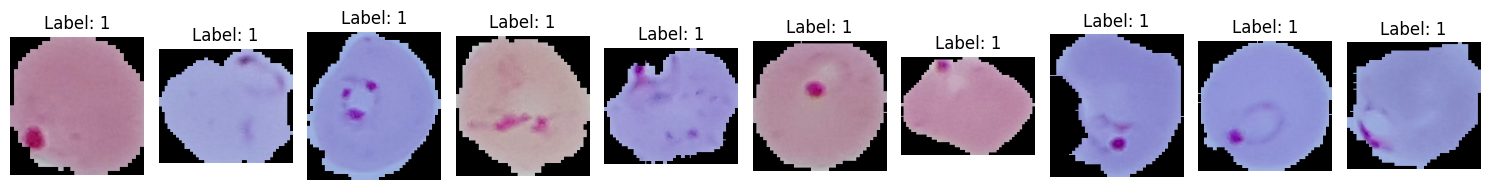

In [ ]:
# Displaying the first 10 images
display_head(X_train, y_train, 10)

In [ ]:
# Resizing the images
X_train_resized = [cv2.resize(img, (130, 130)) if img.shape != (130, 130, 3) else img for img in X_train]
X_test_resized  = [cv2.resize(img, (130, 130)) if img.shape != (130, 130, 3) else img for img in X_test]

# Update the variables
X_train = np.array(X_train_resized)
X_test = np.array(X_test_resized)

In [ ]:
# Checking the new shape
training_shapes = [img.shape for img in X_train]
print(training_shapes)

[(130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130, 3), (130, 130

####<b> Observations and insights:
* Raw images vary in shape, which can impair CNN performance; resizing to a standard shape is essential

* Color of the cells is crucial for the classification


### <b>Check the minimum and maximum range of pixel values for train and test images

In [ ]:
print("Min pixel value in training images:", X_train.min())
print("Max pixel value in training images:", X_train.max())
print("Min pixel value in testing images:", X_test.min())
print("Max pixel value in testing images:", X_test.max())

Min pixel value in training images: 0
Max pixel value in training images: 255
Min pixel value in testing images: 0
Max pixel value in testing images: 255


####<b> Observations and insights:
* Pixel Range (0–255) in both training and testing sets indicates unnormalized image data.

* Normalization is recommended to improve model training stability and performance.

* Consistent min/max values suggest similar preprocessing across datasets.

###<b> Count the number of values in both uninfected and parasitized

In [ ]:
print("Number of parasitized images in training set:", sum(1 for label in y_train if label == 1))
print("Number of uninfected images in training set:", sum(1 for label in y_train if label == 0))
print("Number of parasitized images in testing set:", sum(1 for label in y_test if label == 1))
print("Number of uninfected images in testing set:", sum(1 for label in y_test if label == 0))

Number of parasitized images in training set: 12582
Number of uninfected images in training set: 12376
Number of parasitized images in testing set: 1300
Number of uninfected images in testing set: 1300


###<b>Normalize the images

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

####<b> Observations and insights:
* Pixel are now normalized
* The training and test classes seem balanced at first

###<b> Plot to check if the data is balanced

In [ ]:
def plot_class_distribution(labels, dataset_name='Dataset'):

    # Count the occurrences of each class label
    parasitized_count = sum(1 for label in labels if label == 1)
    uninfected_count = sum(1 for label in labels if label == 0)

    # Create subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Bar plot
    sns.countplot(x=labels, ax=axes[0])
    axes[0].set_title(f'Bar Plot: {dataset_name} Class Distribution')
    axes[0].set_xlabel('Class Label\n(0: Uninfected, 1: Parasitized)')
    axes[0].set_ylabel('Number of Images')

    # Pie chart
    pie_labels = ['Uninfected', 'Parasitized']
    sizes = [uninfected_count, parasitized_count]
    explode = (0.1, 0)

    axes[1].pie(sizes, explode=explode, labels=pie_labels, autopct='%1.1f%%',
                shadow=True, startangle=90)
    axes[1].set_title(f'Pie Chart: {dataset_name}')
    axes[1].axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle

    plt.tight_layout()
    plt.show()

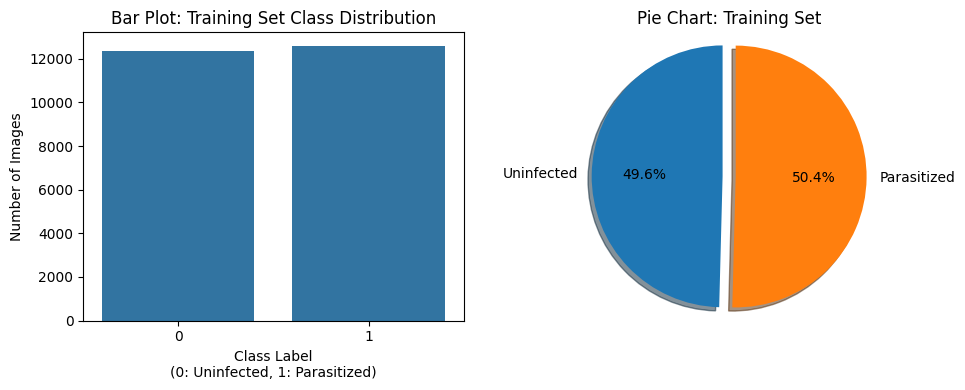

In [ ]:
plot_class_distribution(y_train, 'Training Set')

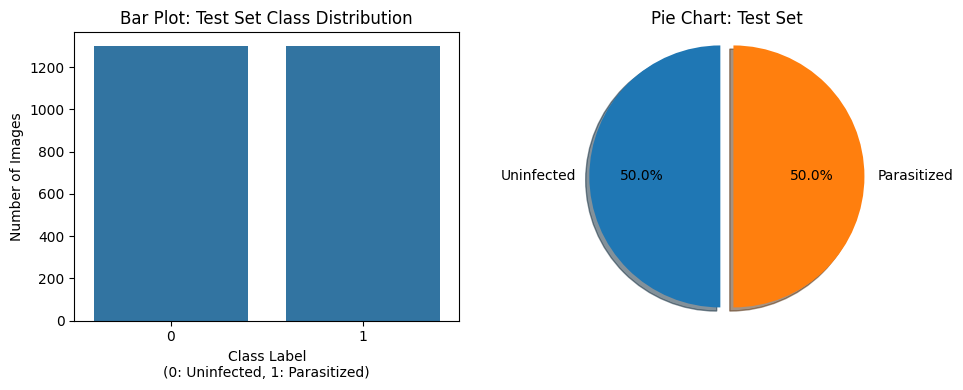

In [ ]:
plot_class_distribution(y_test, 'Test Set')

#### **Observations and insights**:
* Our datasets are well balanced

### <b>Data Exploration</b>
Let's visualize the images from the train data

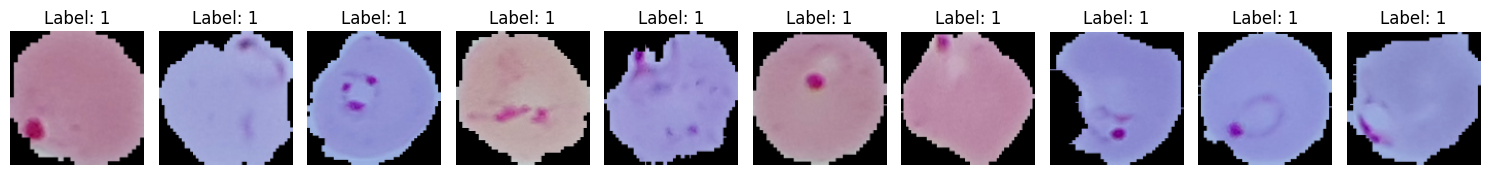

In [ ]:
# Displaying the first 10 images
display_head(X_train, y_train, 10)

#### **Observations and insights**:
✅ Training data is now normalized and rescaled properly

❌ Data may not be shuffled, which can lead to biased training and poor generalization

###<b> Visualize the images with subplot(6, 6) and figsize = (12, 12)

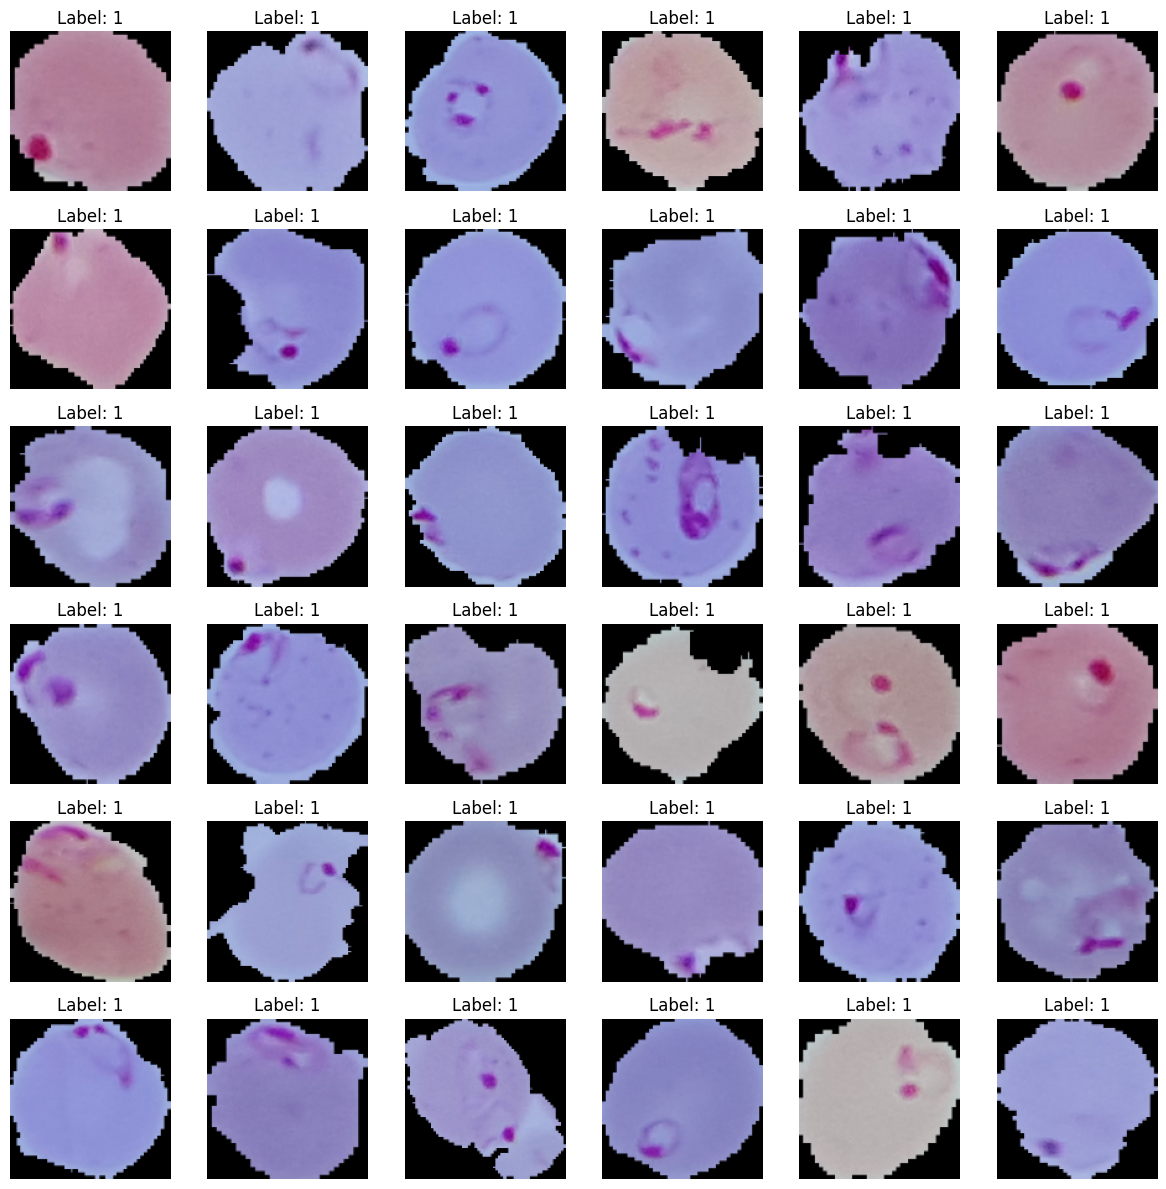

In [ ]:
plt.figure(figsize=(12, 12))
for i in range(36):  # Display 36 images (6x6)
    plt.subplot(6, 6, i + 1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


#### **Observations and insights**:
* Indeed data looks like it's not shuffled

###<b> Plotting the mean images for parasitized and uninfected

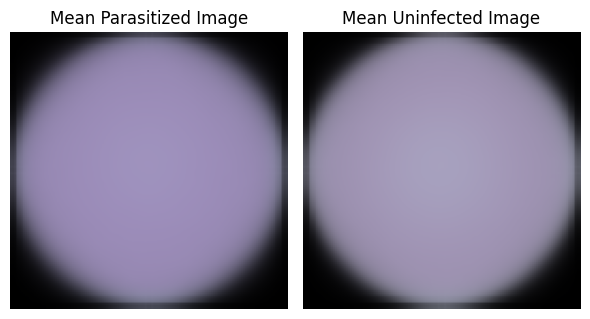

In [ ]:
# Calculate the mean image for parasitized cells
parasitized_indices = [i for i, label in enumerate(y_train) if label == 1]
mean_parasitized_image = np.mean(X_train[parasitized_indices], axis=0)

# Calculate the mean image for uninfected cells
uninfected_indices = [i for i, label in enumerate(y_train) if label == 0]
mean_uninfected_image = np.mean(X_train[uninfected_indices], axis=0)

# Plot the mean images
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(mean_parasitized_image)
plt.title("Mean Parasitized Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mean_uninfected_image)
plt.title("Mean Uninfected Image")
plt.axis('off')

plt.tight_layout()
plt.show()


#### **Observations and insights**:
* By analyzing the mean color values of the images, we observe slight variations between classes, **reinforcing that color plays a significant role** in distinguishing infected and uninfected cells

### <b>Converting RGB to HSV of Images using OpenCV

###<b> Converting the train data

In [ ]:
X_train_hsv = []
for img in X_train.astype(np.float32):
    img_255 = (img * 255).astype(np.uint8)  # Necessary for cvtColor
    hsv_img = cv2.cvtColor(img_255, cv2.COLOR_BGR2HSV)
    X_train_hsv.append(hsv_img)

X_train_hsv = np.array(X_train_hsv) / 255.0  # Normalizes again

###<b> Converting the test data

In [ ]:
X_test_hsv = []
for img in X_test.astype(np.float32):
    img_255 = (img * 255).astype(np.uint8)  # Necessary for cvtColor
    hsv_img = cv2.cvtColor(img_255, cv2.COLOR_BGR2HSV)
    X_test_hsv.append(hsv_img)

X_test_hsv = np.array(X_test_hsv) / 255.0  # Normalizes again

#### **Observations and insights**:
* Using RGB to HSV (Hue, Saturation, Value) facilitates the image processing and enhancing model classification based on colors

###<b> Processing Images using Gaussian Blurring

###<b> Gaussian Blurring on train data

In [ ]:
# Apply Gaussian blur to the training images
X_train_blurred = []
for img in X_train_hsv:
    blurred_img = cv2.GaussianBlur(img, (5, 5), 0)  # kernel size (5, 5)
    X_train_blurred.append(blurred_img)

X_train_blurred = np.array(X_train_blurred)

###<b> Gaussian Blurring on test data

In [ ]:
# Apply Gaussian blur to the testing images
X_test_blurred = []
for img in X_test_hsv:
    blurred_img = cv2.GaussianBlur(img, (5, 5), 0)  # kernel size (5, 5)
    X_test_blurred.append(blurred_img)

X_test_blurred = np.array(X_test_blurred)

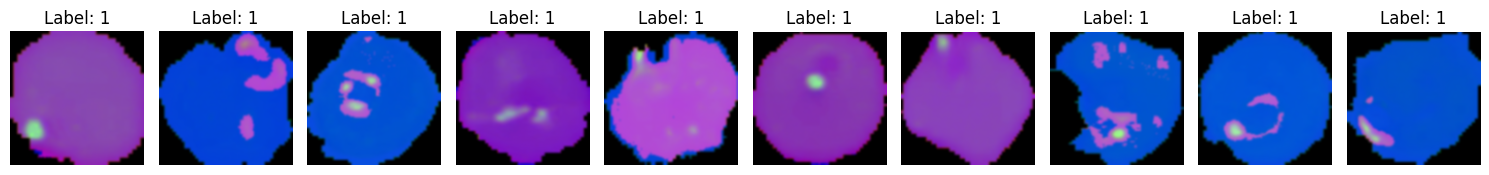

In [ ]:
display_head(X_train_blurred, y_train)

In [ ]:
# Using Garbage Collector to reduce RAM usage
import gc

del X_train
del X_train_hsv
del X_test
del X_test_hsv
del X_train_resized
del X_test_resized
del training_shapes

gc.collect()


87527

#### **Observations and insights:**
* Gaussian blur helps **reducing noise from the images**, also supressing very small details and **highlights larger patterns** — such as the main outlines of the cell.

* At this point, a large amount of memory has been allocated, but most of it wont be used no more. Running **Garbage Collection** helps free up memory and **reduce the computational cost** of the project.

## **Model Building**

### **Base Model**

**Note:** The Base Model has been fully built and evaluated with all outputs shown to give an idea about the process of the creation and evaluation of the performance of a CNN architecture. A similar process can be followed in iterating to build better-performing CNN architectures.

###<b> Importing the required libraries for building and training our Model

In [ ]:
import random

from sklearn.metrics import classification_report, confusion_matrix

import keras
# Keras Sequential Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# Keras Layers
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Activation, LeakyReLU, GlobalAveragePooling2D
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
# Input
from tensorflow.keras import Input
from tensorflow.keras.utils import to_categorical


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


####<B>One Hot Encoding the train and test labels

In [ ]:
y_train_encoded = to_categorical(y_train, num_classes=2)
y_test_encoded = to_categorical(y_test, num_classes=2)

###<b> Building and Compiling the model

In [ ]:
def cnn_model_1():
  # Arquitetura
  model = Sequential([
      # First Convolutional Layer
      Conv2D(32, (3,3), activation='relu', input_shape=(130, 130, 3)),
      MaxPooling2D(pool_size=(2,2)),

      # Second Convolutional Layer
      Conv2D(64, (3,3), activation='relu'),
      MaxPooling2D(pool_size=(2,2)),

      # Third Convolutional Layer
      Conv2D(128, (3,3), activation='relu'),
      MaxPooling2D(pool_size=(2,2)),

      # Flatten for dense layer
      Flatten(),

      # Fully connected layer
      Dense(128, activation='relu'),

      # Output layer for binary classification (1 = Parasitized, 0 = Uninfected)
      Dense(1, activation='sigmoid')
  ])
  model.compile(optimizer=Adam(learning_rate=0.0001),
                loss='binary_crossentropy',
                metrics=['accuracy'])
  return model


In [ ]:
cnn1_model = cnn_model_1()
cnn1_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 62, 62, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 29, 29, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

<b> Using Callbacks

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('first_model.keras', monitor='val_loss', save_best_only=True)

<b> Fit and train our Model

In [ ]:
history = cnn1_model.fit(
    X_train_blurred, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7452 - loss: 0.5209

702/702 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.7453 - loss: 0.5208 - val_accuracy: 0.9159 - val_loss: 0.2826
Epoch 2/20
700/702 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9331 - loss: 0.1726

702/702 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9332 - loss: 0.1725 - val_accuracy: 0.9764 - val_loss: 0.0955
Epoch 3/20
699/702 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9596 - loss: 0.1188

702/702 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9596 - loss: 0.1188 - val_accuracy: 0.9732 - val_loss: 0.0952
Epoch 4/20
700/702 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9667 - loss: 0.0951

702/702 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9668 - loss: 0.0951 - val_accuracy: 0.9856 - val_loss: 0.0765
Epoch 5/20
701/702 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9709 - loss: 0.0816

702/702 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9709 - loss: 0.0816 - val_accuracy: 0.9952 - val_loss: 0.0353
Epoch 6/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9773 - loss: 0.0646 - val_accuracy: 0.9720 - val_loss: 0.1012
Epoch 7/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9785 - loss: 0.0618 - val_accuracy: 0.9848 - val_loss: 0.0855
Epoch 8/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9795 - loss: 0.0577 - val_accuracy: 0.9836 - val_loss: 0.0686


<b>Plotting the train and validation curves

In [ ]:
# Defining the accuracy plot for later use
def plot_train_val_acc(history):
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
  plt.show()

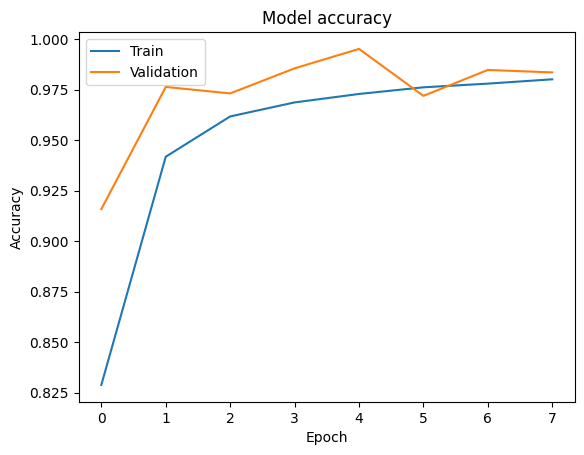

In [ ]:
plot_train_val_acc(history) # plotting model history

###<b> Evaluating the model on test data

In [ ]:
y_pred = cnn1_model.predict(X_test_blurred)

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [ ]:
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = np.argmax(y_test_encoded, axis=1)

In [ ]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1300
           1       0.99      0.94      0.97      1300

    accuracy                           0.97      2600
   macro avg       0.97      0.97      0.97      2600
weighted avg       0.97      0.97      0.97      2600



<b> Plotting the confusion matrix

In [ ]:
# Defining confusion matrix plot for later use
def plot_confusion_matrix(y_true, y_pred):
  conf_matrix = confusion_matrix(y_true, y_pred_classes)
  plt.figure(figsize=(5, 4))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.title('Confusion Matrix')
  plt.show()

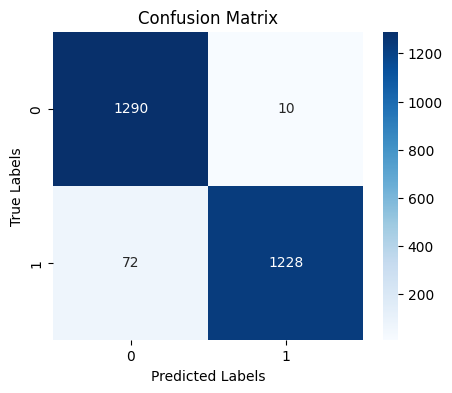

In [ ]:
plot_confusion_matrix(y_true, y_pred_classes)

So now let's try to build another model with few more add on layers and try to check if we can try to improve the model. Therefore try to build a model by adding few layers if required and altering the activation functions.

###<b> Model 1 with Batch Normalization
####<b> Trying to improve the performance of our model by adding new layers


###<b> Building and Compiling the Model

In [ ]:
def cnn_model_2():
    model = Sequential([
        # First Convolutional Block
        Conv2D(
            32, (3, 3),
            activation='relu',
            input_shape=(130, 130, 3),
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Second Convolutional Block
        Conv2D(
            64, (3, 3),
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Third Convolutional Block
        Conv2D(
            128, (3, 3),
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Flatten layer to connect to dense layers
        Flatten(),

        # Dropout to reduce overfitting
        Dropout(0.5),

        # Fully connected layer
        Dense(
            128,
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        Dropout(0.5),

        # Output layer for binary classification (1 = Parasitized, 0 = Uninfected)
        Dense(1, activation='sigmoid')
    ])

    # Compile the model with binary crossentropy loss and accuracy metric
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
cnn2_model = cnn_model_2()
cnn2_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 62, 62, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 62, 62, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 29, 29, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 29, 29, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

<b> Using Callbacks

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('second_model.keras', monitor='val_loss', save_best_only=True)

<b>Fit and Train the model

In [ ]:
history = cnn2_model.fit(
    X_train_blurred, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.7433 - loss: 0.6432 - val_accuracy: 0.9812 - val_loss: 0.1448
Epoch 2/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9262 - loss: 0.2398 - val_accuracy: 0.9908 - val_loss: 0.0939
Epoch 3/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9579 - loss: 0.1688 - val_accuracy: 0.9924 - val_loss: 0.0904
Epoch 4/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9707 - loss: 0.1375 - val_accuracy: 0.9932 - val_loss: 0.0827
Epoch 5/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9723 - loss: 0.1261 - val_accuracy: 0.9728 - val_loss: 0.1715
Epoch 6/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9775 - loss: 0.1139 - val_accuracy: 0.9940 - val_loss: 0.0742
Epoch 7/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9795 - loss: 0.1086 - val_accuracy: 0.9295 - val_loss: 0.3421
Epoch 8/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9793 - loss: 0.1093 - 

<b> Plotting the train and the validation curves

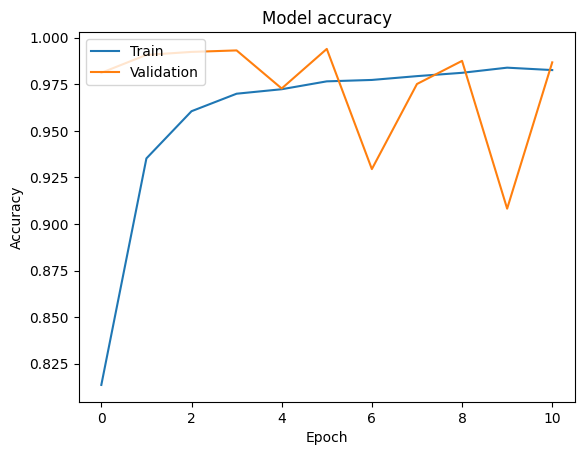

In [ ]:
plot_train_val_acc(history)

###<b> Evaluating the model

In [ ]:
y_pred = cnn1_model.predict(X_test_blurred)

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = np.argmax(y_test_encoded, axis=1)
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1300
           1       0.99      0.94      0.97      1300

    accuracy                           0.97      2600
   macro avg       0.97      0.97      0.97      2600
weighted avg       0.97      0.97      0.97      2600



<b> Plotting the confusion matrix

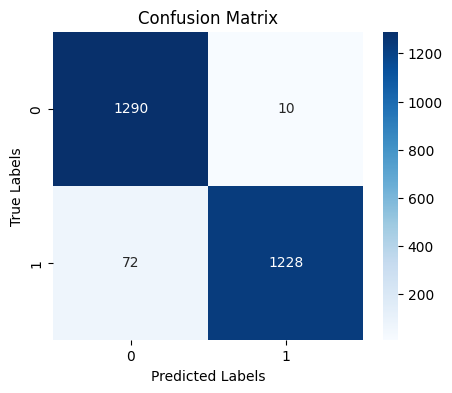

In [ ]:
plot_confusion_matrix(y_true, y_pred)

### **Observation and Insights:**

* The model showed **similar performance** with and without `BatchNormalization()`

* Training and validation accuracies fluctuate throughout training, possibly due to the lack of data shuffling, which may be confusing the model

###<b>Think about it:</b><br>
Now let's build a model with LeakyRelu as the activation function  

*  Can the model performance be improved if we change our activation function to LeakyRelu?
* Can we improve the model with Image Data Augmentation?
Let us try to build a model using BatchNormalization and using LeakyRelu as our activation function.
  *   [Image Augmentation for Computer Vision](https://www.mygreatlearning.com/blog/understanding-data-augmentation/)
  *   [How to Configure Image Data Augmentation in Keras?](https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/)


###<b>Model 2 with Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Generator com Data Augmentation para o conjunto de treinamento
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.1  # se quiser usar um pedaço do treino como validação
)

###<b> Use image data generator

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_blurred, y_train,
    test_size=0.1,  # 10% para validação
    random_state=42,
    stratify=y_train
)

In [ ]:
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=32,
    shuffle=True
)


In [ ]:
val_datagen = ImageDataGenerator()

val_generator = val_datagen.flow(
    X_val, y_val,
    batch_size=32,
    shuffle=False
)

####<B>Visualizing Augmented images

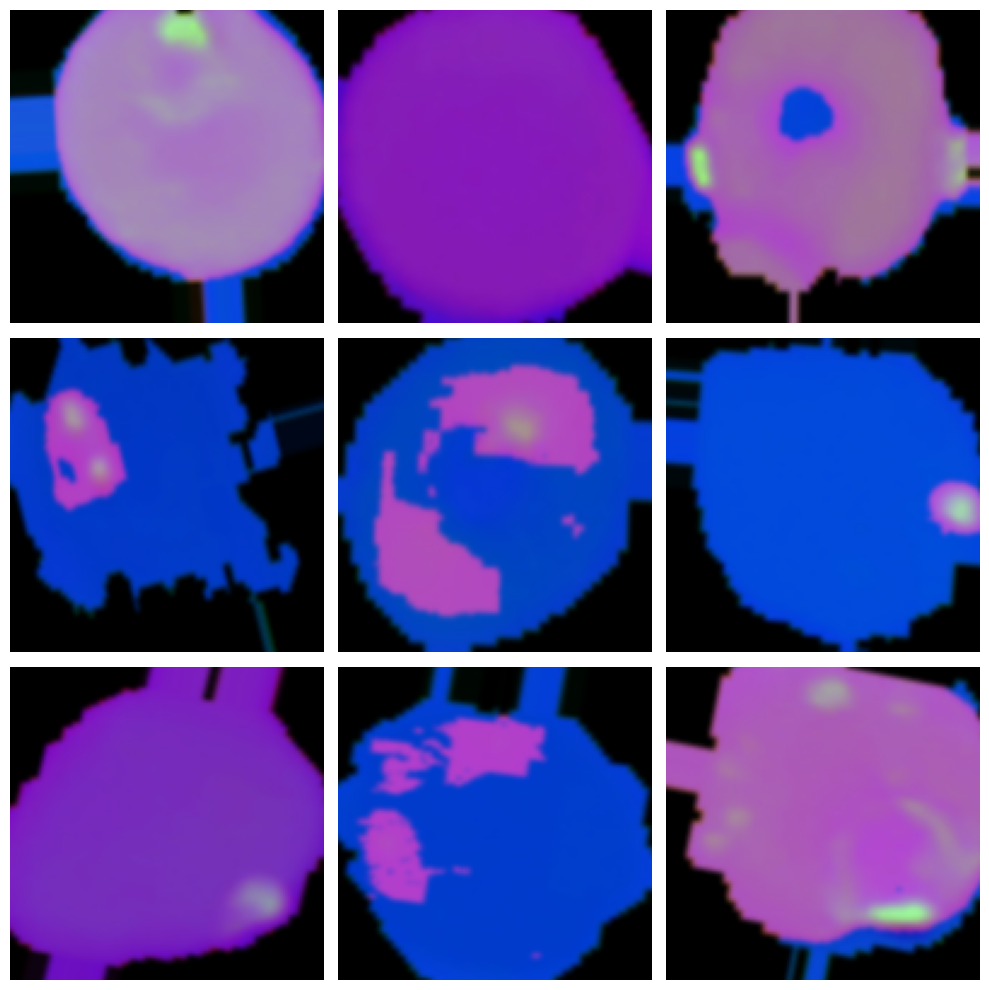

In [ ]:
plt.figure(figsize=(10,10))
for i in range(9):
    image, label = next(train_generator)
    img = image[0] * 255.0  # Denormalize
    img = img.astype("uint8")
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

#### **Observations and insights**:



###<b>Building and Compiling the Model

In [ ]:
from tensorflow.keras.layers import LeakyReLU


def cnn_model_2(input_shape=(130, 130, 3)):
    model = Sequential([
        # Bloco 1: Conv -> BN -> LeakyReLU -> Pool
        Conv2D(
            32, (3, 3),
            padding='same',
            kernel_regularizer=regularizers.l2(1e-4),
            input_shape=input_shape
        ),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.2),
        MaxPooling2D(pool_size=(2, 2)),

        # Bloco 2
        Conv2D(
            64, (3, 3),
            padding='same',
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.2),
        MaxPooling2D(pool_size=(2, 2)),

        # Bloco 3
        Conv2D(
            128, (3, 3),
            padding='same',
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.2),
        MaxPooling2D(pool_size=(2, 2)),

        # Flatten
        Flatten(),

        # Densa + LeakyReLU + Dropout
        Dropout(0.5),
        Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.2),
        Dropout(0.5),

        # Saída binária
        Dense(1, activation='sigmoid')
    ])

    # Compilando o modelo
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model



In [ ]:
cnn2_model = cnn_model_2()
cnn2_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 130, 130, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 130, 130, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 130, 130, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 65, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 65, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 65, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 65, 65, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       4,194,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 4,289,217 (16.36 MB)

 Trainable params: 4,288,513 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

<b>Using Callbacks

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('third_model.keras', monitor='val_loss', save_best_only=True)

<b> Fit and Train the model

In [ ]:
history = cnn2_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 88s 114ms/step - accuracy: 0.7532 - loss: 0.5741 - val_accuracy: 0.9375 - val_loss: 0.2332
Epoch 2/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.9109 - loss: 0.2771 - val_accuracy: 0.9547 - val_loss: 0.1747
Epoch 3/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.9330 - loss: 0.2283 - val_accuracy: 0.9611 - val_loss: 0.1525
Epoch 4/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.9479 - loss: 0.1914 - val_accuracy: 0.9643 - val_loss: 0.1466
Epoch 5/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.9523 - loss: 0.1790 - val_accuracy: 0.9619 - val_loss: 0.1422
Epoch 6/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.9535 - loss: 0.1753 - val_accuracy: 0.9716 - val_loss: 0.1283
Epoch 7/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 78s 112ms/step - accuracy: 0.9595 - loss: 0.1682 - val_accuracy: 0.9696 - val_loss: 0.1287
Epoch 8/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.9576 - loss: 0

###<B>Evaluating the model

<b>Plot the train and validation accuracy

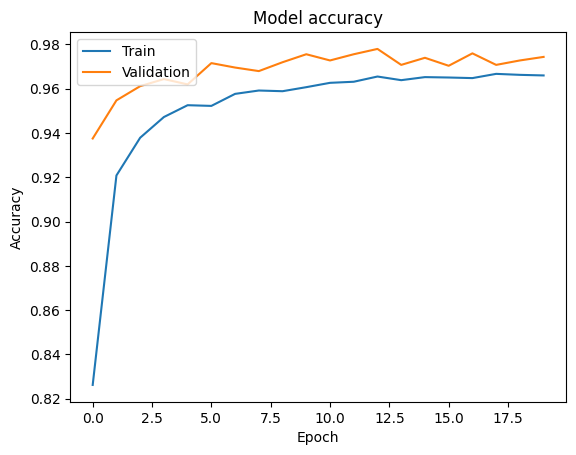

In [ ]:
plot_train_val_acc(history)

<B>Plotting the classification report and confusion matrix

In [ ]:
y_pred = cnn2_model.predict(X_test_blurred)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = np.argmax(y_test_encoded, axis=1)

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


In [ ]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1300
           1       0.98      0.98      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



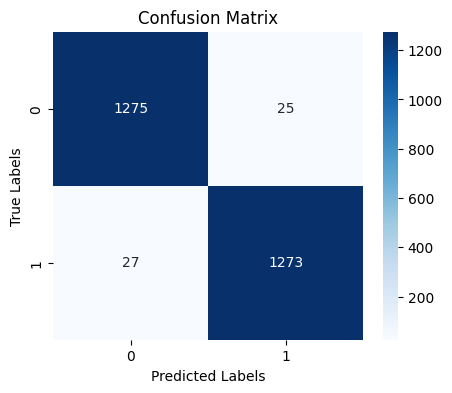

In [ ]:
plot_confusion_matrix(y_true, y_pred)

<b> Now, let us try to use a pretrained model like VGG16 and check how it performs on our data.

### **Pre-trained model (VGG16)**
- Import VGG16 network upto any layer you choose
- Add Fully Connected Layers on top of it

###<b>Compiling and Building the model

In [ ]:
from tensorflow.keras.applications import VGG16

def vgg16_model():

  # Load the VGG16 model pre-trained on ImageNet, excluding the top layers
  base_model = VGG16(weights='imagenet', include_top=False, input_shape=(130, 130, 3))

  # Freeze the layers of the base model (optional, but often recommended)
  for layer in base_model.layers:
    layer.trainable = False

  # Add custom classification layers on top of the base model
  x = base_model.output
  x = Flatten()(x)
  x = Dense(256, activation='relu')(x)  # Fully connected layer
  predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

  # Create the final model
  model = Model(inputs=base_model.input, outputs=predictions)

  # Compile the model
  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']
      )

  return model

In [ ]:
vgg_model = vgg16_model()
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 130, 130, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 130, 130, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 130, 130, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 65, 65, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 65, 65, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 65, 65, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

<b> Using Callbacks

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('vgg16_model.keras', monitor='val_loss', save_best_only=True)

<b>Fit and Train the model

In [ ]:
history = vgg_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
)


Epoch 1/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 99s 129ms/step - accuracy: 0.7411 - loss: 0.5652 - val_accuracy: 0.8606 - val_loss: 0.3422
Epoch 2/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.8286 - loss: 0.3820 - val_accuracy: 0.8570 - val_loss: 0.3207
Epoch 3/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.8378 - loss: 0.3577 - val_accuracy: 0.8614 - val_loss: 0.3172
Epoch 4/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.8445 - loss: 0.3464 - val_accuracy: 0.8462 - val_loss: 0.3491
Epoch 5/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.8472 - loss: 0.3391 - val_accuracy: 0.8642 - val_loss: 0.2991
Epoch 6/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.8558 - loss: 0.3217 - val_accuracy: 0.8606 - val_loss: 0.3413
Epoch 7/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.8648 - loss: 0.3133 - val_accuracy: 0.8818 - val_loss: 0.2801
Epoch 8/20
702/702 ━━━━━━━━━━━━━━━━━━━━ 83s 119ms/step - accuracy: 0.8617 - loss: 0

<b>Plot the train and validation accuracy

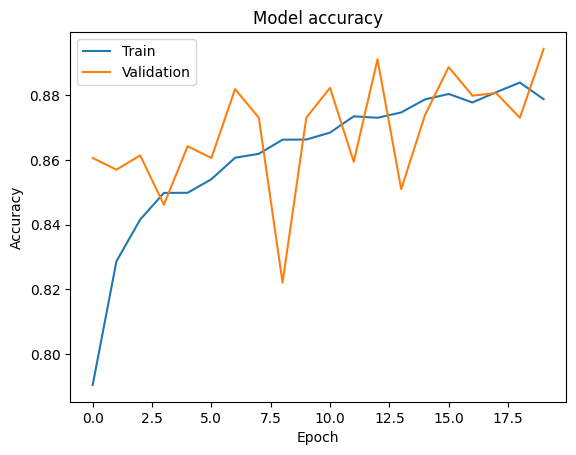

In [ ]:
plot_train_val_acc(history)

###<b> Evaluating the model

In [ ]:
y_pred = vgg_model.predict(X_test_blurred)

82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step


In [ ]:
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = np.argmax(y_test_encoded, axis=1)

<b>Plotting the classification report and confusion matrix

In [ ]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1300
           1       0.85      0.90      0.88      1300

    accuracy                           0.87      2600
   macro avg       0.88      0.87      0.87      2600
weighted avg       0.88      0.87      0.87      2600



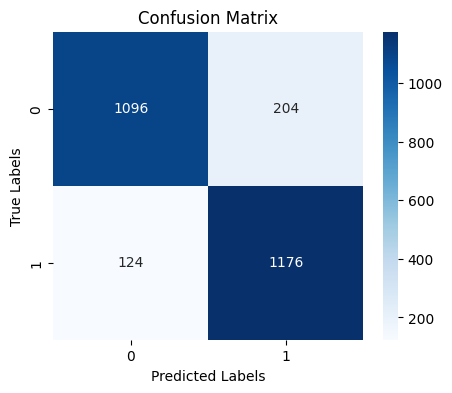

In [ ]:
plot_confusion_matrix(y_true, y_pred)

### **Observations and insights:**
* The Transfer Learning model achieved good accuracy (87%) with balanced f1-scores, but accuracy fluctuations indicates a poor training stability

* This was expected, since the VGG16 model **was trained on natural images, not medical/microscopic ones**. Also the VGG16 model expect **different sizes input** (224x224 instead of 130x130)

## 🏆 Best Model: Model 2 (Data Augmentation)

* Despite a slight drop in validation accuracy (0.973 vs. 0.984), it demonstrates **greater robustness and generalization**.

* Data Augmentation introduced controlled variability to the training data through transformations

* Achieved the lowest number of false positives and false negatives.

* Ideal for clinical scenarios where **minimizing false negatives is critical** (only 27 in this model vs. 72 in the others)


In [ ]:
cnn2_model.save('final_model.keras')

#### 🔧 Suggestions of Improvements for the Final Model

• **Use Focal Loss**
Replace ``binary cross-entropy`` with ``Focal Loss`` to focus on hard examples and `**reduce false negatives** by penalizing misclassified infected cells more heavily.

• **Use GlobalAveragePooling2D**
Swap ``Flatten()`` with ``GlobalAveragePooling2D()`` to reduce overfitting and enhance spatial feature extraction, improving generalization.

• **Apply Learning Rate Scheduling**
Use ``ReduceLROnPlateau`` or similar to adjust the learning rate during training, aiding convergence and helping the model capture subtle patterns.

## **💡 Final Insights and Recommendations**

* **Our final model demonstrates strong performance and appears ready for deployment in real-world scenarios**, showing high confidence in classifying infected and uninfected cells.

* Despite the high accuracy (~98%), some False Negatives still occur. In medical applications, **minimizing False Negatives is critical**, as misclassifying an infected patient as healthy can have serious consequences. It is generally preferable to err on the side of caution—even if it means occasionally misclassifying a healthy individual.

* Using pre-trained models is often a good strategy to improve generalization and robustness. However, in our case, the VGG16 model did not perform satisfactorily—likely due to differences between the pre-training dataset and our own data.

* When applying Transfer Learning, I recommend analyzing the compatibility between your dataset and the pre-trained model. Key aspects to compare include the similarity of the environments, the shape and type of input images, and the performance of the pre-trained model on related tasks.


#🧾 Executive Summary

The analysis performed during the Milestone phase revealed that deep learning, specifically Convolutional Neural Networks (CNNs), can accurately classify blood smear images into infected and uninfected categories with high performance. Among the tested models, Model 2 with Data Augmentation emerged as the best choice. Although it slightly underperformed in raw accuracy (97.3% vs. 98.4%), it achieved significantly fewer false negatives, which is critical in a medical context.

## Final Model Specifications:

* Architecture: Custom CNN with multiple convolutional, max-pooling, and dense layers.

* Preprocessing: Normalization + Data Augmentation (zoom, flip, rotation).

* Loss Function: Binary Crossentropy (recommendation to upgrade to Focal Loss).

* Best Performance:

  * Accuracy ≈ 97.3%

  * False Negatives: 27 (vs. 72 in other models)

  * Saved as: final_model.keras

This model shows robust generalization and is clinically promising due to its high sensitivity and low false negative rate.

# 🧩 Problem and Solution Summary

## Problem Summary:
Malaria remains a global health concern, especially in regions with limited access to healthcare. Misdiagnosis or delayed diagnosis can lead to severe complications or death. Traditional diagnostics rely heavily on manual microscopy, which is time-consuming and prone to human error.

## Solution Rationale:
To mitigate this, we proposed a CNN-based classifier that automates the detection of malaria-infected cells. The goal was to reduce diagnostic time, improve accuracy, and scale access to early detection in remote settings.

## Business Impact:
Implementing this model in clinical or remote diagnostic tools can:

* Improve early detection rates

* Reduce burden on medical staff

* Enable scalability in underserved regions

* Minimize false negatives, which is paramount in healthcare

# 🧠 Recommendations for Implementation

## Key Recommendations:

* Integrate Focal Loss to reduce false negatives by emphasizing hard-to-classify cases.

* Replace Flatten with GlobalAveragePooling2D to reduce overfitting and improve spatial generalization.

* Apply Learning Rate Schedulers (e.g., ReduceLROnPlateau) for better convergence.

## Actionables for Stakeholders:

* Deploy the model in a web/mobile interface for use in rural clinics.

* Perform pilot testing with local hospitals to evaluate usability and trust.

* Train local health workers to interpret model outputs and limitations.

## Expected Benefits:

* Faster and more consistent diagnostics

* Reduced operational burden in resource-constrained settings

* Higher patient throughput and potentially reduced mortality

## Risks and Challenges:

* Risk of over-reliance without human validation

* Potential bias due to dataset limitations

* Need for regulatory approvals before clinical deployment

## Further Analysis Needed:

* Evaluate performance across diverse image sources and microscope settings

* Conduct external validation using datasets from different regions

* Explore model interpretability techniques (e.g., Grad-CAM) to assist medical professionals

